# Part 3

In [1]:
import pandas as pd
import time
import matplotlib.pyplot as plt
from pyspark.sql.functions import col, window, avg, to_timestamp
from pyspark.sql import SparkSession

existing = SparkSession.getActiveSession()
if existing:
    existing.stop()

spark = (
    SparkSession.builder
    .appName('Journey-Part3')
    .master('spark://127.0.0.1:7077')
    .config('spark.driver.host', '127.0.0.1')
    .config('spark.driver.bindAddress', '127.0.0.1')
    .getOrCreate()
)
spark

In [2]:
df = pd.read_csv('/home/bfh/rtdp/bfh-rtdp/roller/RawData.csv', sep=';', decimal=',')
df.columns = ['time_s', 'gx', 'gy', 'gz', 'absolute']
df['timestamp'] = df['time_s'] + time.time()

df.head()

,time_s,gx,gy,gz,absolute,timestamp
0,0.021205,0.004554,-0.018110,0.007252,0.020033,1.780144e+09
1,0.031272,0.035954,-0.021800,0.012549,0.043880,1.780144e+09
2,0.041339,0.058538,-0.047381,0.004798,0.075464,1.780144e+09
3,0.051406,0.066985,-0.087119,0.013295,0.110696,1.780144e+09
4,0.061473,0.071572,-0.115078,0.017367,0.136627,1.780144e+09


In [3]:
sdf = spark.createDataFrame(df[['timestamp', 'gx', 'gy', 'gz', 'absolute']]) \
    .withColumn('zeit', to_timestamp(col('timestamp').cast('long')))

result = (
    sdf.groupBy(window('zeit', '1 second'))
    .agg(avg('absolute').alias('avg_absolute'))
    .orderBy('window')
    .select(col('window.start').alias('start'), 'avg_absolute')
    .toPandas()
)

result.head()

ERROR:root:KeyboardInterrupt while sending command.                 (0 + 0) / 2]
Traceback (most recent call last):
  File "/home/bfh/.local/lib/python3.10/site-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
  File "/home/bfh/.local/lib/python3.10/site-packages/py4j/clientserver.py", line 511, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
  File "/usr/lib/python3.10/socket.py", line 705, in readinto
    return self._sock.recv_into(b)
KeyboardInterrupt


KeyboardInterrupt: 

14:31:24.535 [dispatcher-event-loop-0] ERROR org.apache.spark.scheduler.cluster.StandaloneSchedulerBackend - Application has been killed. Reason: Master removed our application: KILLED
14:31:24.583 [dispatcher-event-loop-0] ERROR org.apache.spark.rpc.netty.Inbox - Ignoring error
org.apache.spark.SparkException: Exiting due to error from cluster scheduler: Master removed our application: KILLED
	at org.apache.spark.errors.SparkCoreErrors$.clusterSchedulerError(SparkCoreErrors.scala:291) ~[spark-core_2.12-3.5.0.jar:3.5.0]
	at org.apache.spark.scheduler.TaskSchedulerImpl.error(TaskSchedulerImpl.scala:981) ~[spark-core_2.12-3.5.0.jar:3.5.0]
	at org.apache.spark.scheduler.cluster.StandaloneSchedulerBackend.dead(StandaloneSchedulerBackend.scala:165) ~[spark-core_2.12-3.5.0.jar:3.5.0]
	at org.apache.spark.deploy.client.StandaloneAppClient$ClientEndpoint.markDead(StandaloneAppClient.scala:263) ~[spark-core_2.12-3.5.0.jar:3.5.0]
	at org.apache.spark.deploy.client.StandaloneAppClient$ClientEndpo

In [ ]:
axes_result = (
    sdf.groupBy(window('zeit', '1 second'))
    .agg(avg('gx').alias('avg_gx'), avg('gy').alias('avg_gy'), avg('gz').alias('avg_gz'))
    .orderBy('window')
    .select(col('window.start').alias('start'), 'avg_gx', 'avg_gy', 'avg_gz')
    .toPandas()
)

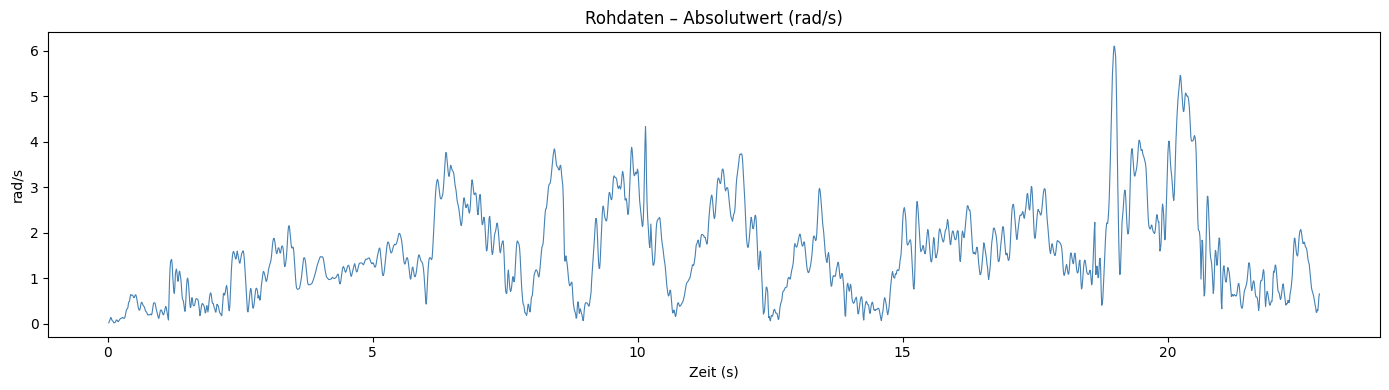

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['time_s'], df['absolute'], linewidth=0.8, color='steelblue')
ax.set_title('Rohdaten – Absolutwert (rad/s)')
ax.set_xlabel('Zeit (s)')
ax.set_ylabel('rad/s')
plt.tight_layout()
plt.show()

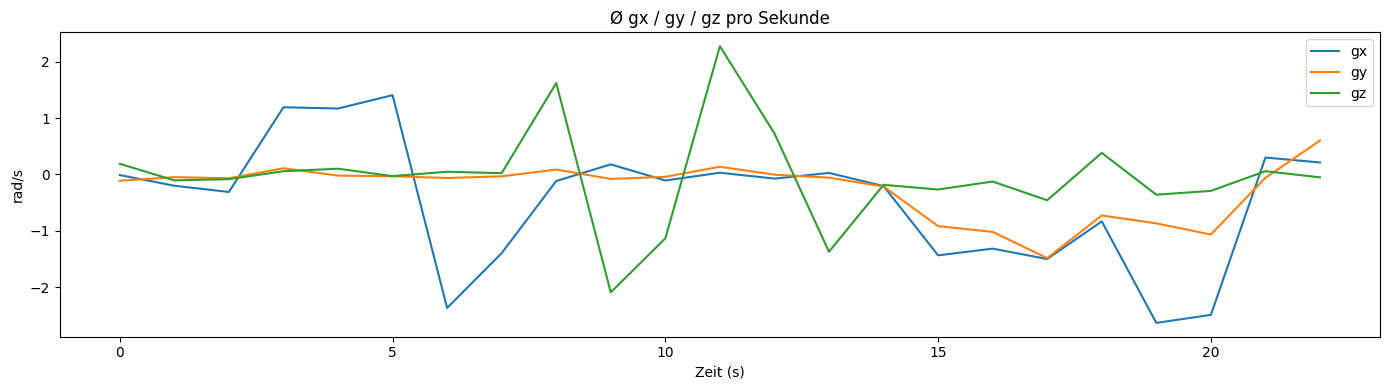

In [ ]:


t = (axes_result['start'] - axes_result['start'].min()).dt.total_seconds()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t, axes_result['avg_gx'], label='gx')
ax.plot(t, axes_result['avg_gy'], label='gy')
ax.plot(t, axes_result['avg_gz'], label='gz')
ax.set_title('Ø gx / gy / gz pro Sekunde')
ax.set_xlabel('Zeit (s)')
ax.set_ylabel('rad/s')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
from pyspark.sql.functions import rand, sqrt, lit

# Repeat the dataset 2^13 = 8192x → millions of rows
big = sdf
for _ in range(13):
    big = big.union(sdf)

big = big.withColumn('noise', rand() * 0.1) \
         .withColumn('abs_noisy', sqrt(
             (col('gx') + col('noise'))**2 +
             (col('gy') + col('noise'))**2 +
             (col('gz') + col('noise'))**2
         ))

result_big = (
    big.groupBy(window('zeit', '1 second'))
    .agg(
        avg('abs_noisy').alias('avg_abs'),
        avg('gx').alias('avg_gx'),
        avg('gy').alias('avg_gy'),
        avg('gz').alias('avg_gz'),
    )
    .orderBy('window')
    .select(col('window.start').alias('start'), 'avg_abs', 'avg_gx', 'avg_gy', 'avg_gz')
    .toPandas()
)

print(f"Rows processed: {big.count():,}")
result_big.head()

Rows processed: 31,780


,start,avg_abs,avg_gx,avg_gy,avg_gz
0,2026-05-30 13:49:03,0.317710,-0.010732,-0.112199,0.189015
1,2026-05-30 13:49:04,0.550624,-0.200443,-0.047640,-0.105117
2,2026-05-30 13:49:05,0.786590,-0.311135,-0.067937,-0.084059
3,2026-05-30 13:49:06,1.376504,1.193536,0.109868,0.057304
4,2026-05-30 13:49:07,1.257558,1.171561,-0.020572,0.102241
